In [1]:
import sklearn
from sklearn.datasets import make_circles
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
from tqdm.auto import tqdm

import torch
from torch import nn

from sklearn.model_selection import train_test_split
from helper_functions import plot_predictions, plot_decision_boundary
from helper_functions import accuracy_fn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

from torch.utils.data import DataLoader

print(torch.__version__)
print(torchvision.__version__)

1.11.0
0.12.0


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
train_data = datasets.FashionMNIST(
    root="data", 
    train = True, 
    download = True, 
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

test_data = datasets.FashionMNIST(
    root="data", 
    train = False, 
    download = True, 
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

'''
Transforms - Converts an Image or numpy.ndarray (H x W x C) in the range [0,255] to a 
torch.Float Tensor of shape (C x H x W).

'''

'\nTransforms - Converts an Image or numpy.ndarray (H x W x C) in the range [0,255] to a \ntorch.Float Tensor of shape (C x H x W).\n\n'

In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
image, label = train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [15]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [17]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [19]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [21]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

Text(0.5, 1.0, '9')

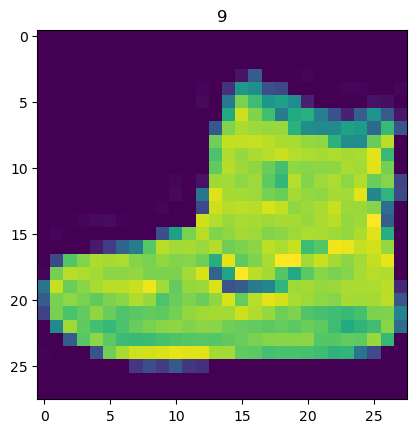

In [23]:
plt.imshow(image.squeeze())
plt.title(label)

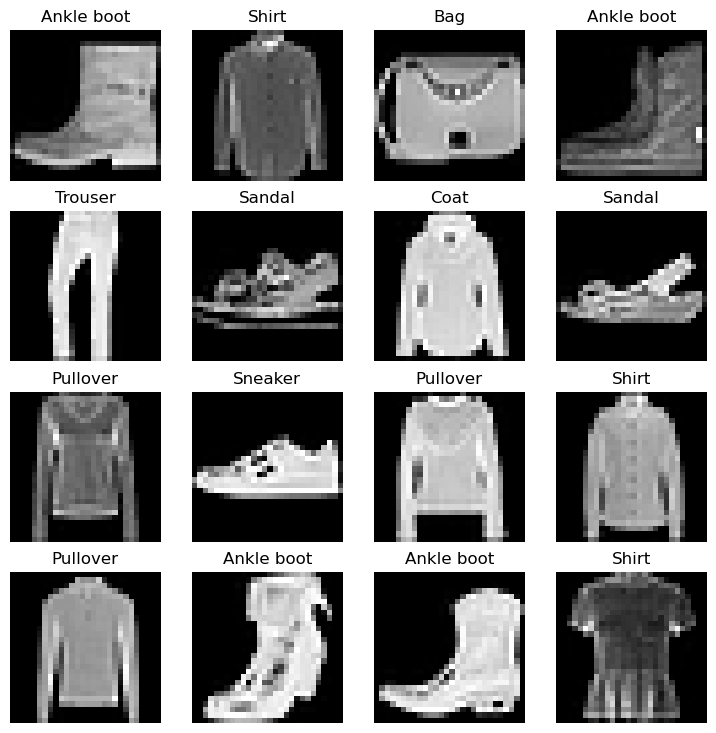

In [21]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size = [1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows,cols, i)
    plt.imshow(img.squeeze(),cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [25]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset = train_data, batch_size = BATCH_SIZE, shuffle = True, num_workers=0
)

test_dataloader = DataLoader(
    dataset = test_data, batch_size = BATCH_SIZE, shuffle = False, num_workers=0
)

train_dataloader

In [27]:
print(f"DataLoaders: {train_dataloader}, \nLen of train dataloader: {len(train_dataloader)}")

DataLoaders: <torch.utils.data.dataloader.DataLoader object at 0x0000026229AB0E50>, 
Len of train dataloader: 1875


In [29]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(-0.5, 27.5, 27.5, -0.5)

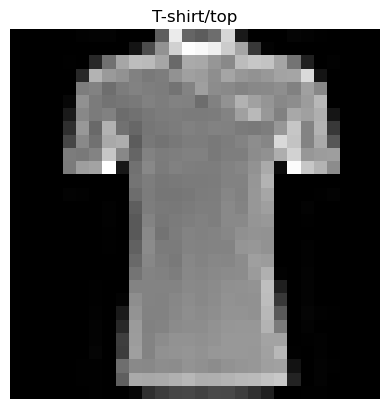

In [31]:
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img,label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False)

In [33]:
flatten_model = nn.Flatten()

x = train_features_batch[0]
x.shape

torch.Size([1, 28, 28])

In [35]:
output = flatten_model(x)
output.shape

torch.Size([1, 784])

In [28]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, hidden_units),
            nn.Linear(hidden_units, output_shape) 
        )
    def forward(self, x):
        return self.layer_stack(x)        

In [30]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape = 28*28, hidden_units = 10, output_shape=len(class_names)).to(device)
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [128]:
#dummy_x = torch.rand([1,1,28,28])
#model_0(dummy_x)

In [129]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]],
                     device='cuda:0')),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163], device='cuda:0')),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0

In [25]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr=0.1)

NameError: name 'model_0' is not defined

In [39]:
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time: .3f} seconds")
    return total_time

In [132]:
start_time = timer()
#asd
end_time = timer()
print_train_time(start_time, end_time, device=device)

Train time on cuda:  0.000 seconds


6.299999949987978e-05

In [133]:
torch.manual_seed(42)
start_time = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----")

    train_loss = 0

    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()

        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples.")

    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0, 0
    model_0.eval()

    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X)
            test_loss += loss_fn(test_pred, y)

            test_acc += accuracy_fn(y, test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

end_time = timer()
total_time = print_train_time(start_time, end_time, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_addmm)

In [32]:
#EVAL

torch.manual_seed(42)
def eval_model(model: torch.nn.Module, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, accuracy_fn):
    loss, acc = 0,0 
    model.eval()

    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            y_pred = model(X)

            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y, y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, 
            "model_loss": loss.item(),
            "model_acc": acc}

model_0_results = eval_model(model= model_0, data_loader = test_dataloader, loss_fn = loss_fn, accuracy_fn = accuracy_fn)

model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_addmm)

In [95]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, output_shape),
            nn.ReLU()
        )
    def forward(self, x):
        return self.layer_stack(x)        

In [97]:
torch.manual_seed(42)

model_1 = FashionMNISTModelV1(input_shape = 28*28, hidden_units = 10, output_shape=len(class_names)).to(device)
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [41]:
#16:43:30

In [43]:
model_1

FashionMNISTModelV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [87]:
def train_step(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer, 
               accuracy_fn = accuracy_fn, 
               device: torch.device = device):
    
    train_loss, train_acc = 0,0
    model.to(device)
    model.train()
    
    for batch, (X,y) in enumerate(data_loader):
        X,y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y,y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #if batch % 400 == 0:
        #    print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples.")

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f"Train Loss: {train_loss:.5f} | Train Acc: {train_acc:.2f}%\n")
    

In [89]:
def test_step(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer, 
               accuracy_fn = accuracy_fn, 
               device: torch.device = device):
    
    test_loss, test_acc = 0,0
    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X,y in data_loader:
            X,y = X.to(device), y.to(device)

            test_pred = model(X)

            test_loss += loss_fn(test_pred,y)
            test_acc += accuracy_fn(y,test_pred.argmax(dim=1))

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        print(f"Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%\n")
    

In [ ]:
torch.manual_seed(42)

train_time_start = timer()

epochs=3

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr=0.1)

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}")
    train_step(model_1, train_dataloader, optimizer, accuracy_fn, device)

    test_step(model_1, test_dataloader, optimizer, accuracy_fn, device)

tran_time_end = timer()
total_train_time = print_train_time(train_time_start,tran_time_end, device)

In [ ]:
model_0_results

In [81]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int): #(self,1,10,10)
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride = 2) # Takes Max value inside the window and divides input by 2 by converting a 2x2 matrix into 1
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units*7*7, output_shape) 
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block1(x)
        #print(x.shape)
        x = self.conv_block2(x)
        #print(x.shape)
        x = self.classifier(x)
        return x        

In [47]:
len(class_names)

10

In [49]:
image.shape

torch.Size([1, 28, 28])

In [51]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, hidden_units = 10, output_shape = len(class_names)).to(device)

In [52]:
torch.manual_seed(42)

images = torch.randn(size = (32,3,64,64))
test_image = images[0]

print(f"Input Batch shape: {images.shape}")
print(f"Single Image Shape: {test_image.shape}")
print(f"Length of images: {len(images)}")
print(f"Test Image: \n{test_image}")

Input Batch shape: torch.Size([32, 3, 64, 64])
Single Image Shape: torch.Size([3, 64, 64])
Length of images: 32
Test Image: 
tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.

In [74]:
conv_layer = nn.Conv2d(3,10,kernel_size = 3, stride = 1, padding = 1)

conv_output = conv_layer(test_image.unsqueeze(0))
conv_output.shape

torch.Size([1, 10, 64, 64])

In [93]:
#18:12:00

In [79]:
rand_image_tensor = torch.randn(size=(1,28,28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [81]:
model_2(rand_image_tensor.unsqueeze(0).to(device))

torch.Size([1, 10, 14, 14])
torch.Size([1, 10, 7, 7])


tensor([[ 0.0426, -0.0984,  0.0621, -0.0358,  0.0184,  0.0271,  0.0163,  0.0133,
         -0.0038, -0.0115]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [55]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_2.parameters(), lr = 0.1)

In [91]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

train_time_start = timer()

epochs=3


for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}")
    
    train_step(model_2, train_dataloader,loss_fn, optimizer, accuracy_fn, device)

    test_step(model_2, test_dataloader,loss_fn, optimizer, accuracy_fn, device)

tran_time_end = timer()
total_train_time = print_train_time(train_time_start,tran_time_end, device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Train Loss: 0.30023 | Train Acc: 89.14%

Test Loss: 0.30927 | Test Acc: 89.03%

Epoch: 1
Train Loss: 0.28525 | Train Acc: 89.69%

Test Loss: 0.30288 | Test Acc: 89.00%

Epoch: 2
Train Loss: 0.27645 | Train Acc: 89.90%

Test Loss: 0.28603 | Test Acc: 89.68%

Train time on cuda:  52.023 seconds


In [121]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)
            pred_logit = model(sample)

            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)

In [149]:
import random
random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k = 9):
    test_samples.append(sample)
    test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

In [150]:
#print(test_data[0][:2])
img, label = test_data[0][:2]
img.shape, label

(torch.Size([1, 28, 28]), 9)

Text(0.5, 1.0, 'Sandal')

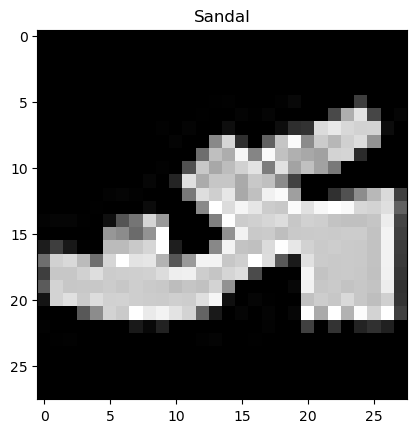

In [151]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [152]:
pred_probs = make_predictions(model_2, test_samples)

pred_probs[:2]

tensor([[3.3762e-10, 1.0209e-10, 6.8591e-10, 3.9901e-10, 4.2952e-10, 9.9999e-01,
         3.5828e-09, 2.1679e-07, 2.9305e-07, 8.9746e-06],
        [2.3395e-02, 9.4016e-01, 3.0817e-04, 8.8629e-03, 8.0886e-03, 1.1155e-05,
         1.9009e-02, 5.3233e-05, 8.8762e-05, 2.3174e-05]])

In [153]:
# Convert prediciton probabilities into labels

pred_classes = pred_probs.argmax(dim=1)
class_names[pred_classes[0]]

'Sandal'

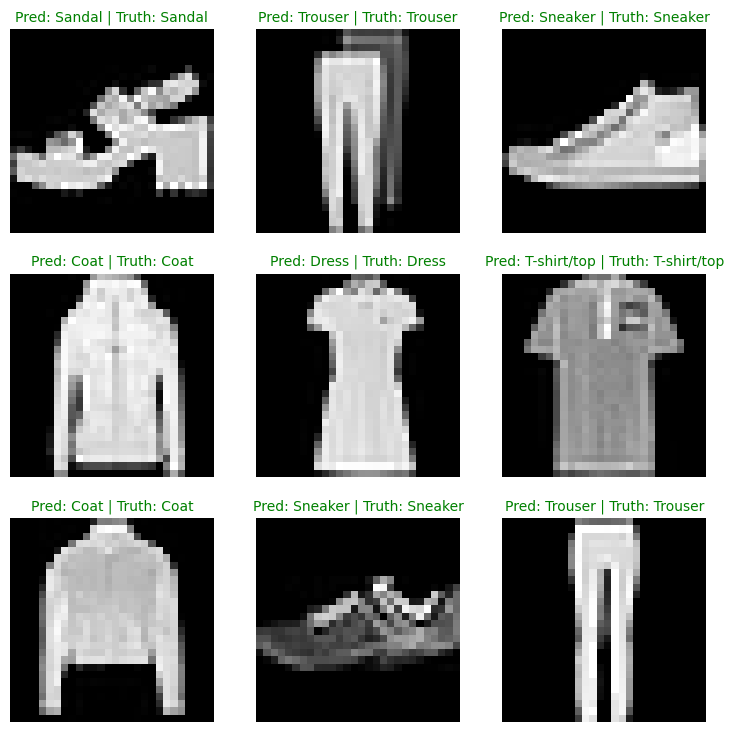

In [156]:
plt.figure(figsize=(9,9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    plt.subplot(nrows,ncols, i+1)
    plt.imshow(sample.squeeze(), cmap="gray")

    pred_label = class_names[pred_classes[i]]
    truth_label = class_names[test_labels[i]]

    title_text = f"Pred: {pred_label} | Truth: {truth_label}"
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize = 10, c="r")
    plt.axis(False)

In [169]:
from tqdm.auto import tqdm

y_preds = []
model_2.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc = "Making Predictions..."):
        X, y = X.to(device), y.to(device)
        y_logits = model_2(X)
        y_pred = torch.softmax(y_logits.squeeze(), dim=0).argmax(dim=1)
        y_preds.append(y_pred.cpu())

    #print(y_preds)
    y_pred_tensor = torch.cat(y_preds)
    print(y_pred_tensor)


Making Predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 2])


In [181]:
!pip install torchmetrics

   ---------------------------------------- 0.0/891.4 kB ? eta -:--:--
   ---------------------------------------- 10.2/891.4 kB ? eta -:--:--
   --- ----------------------------------- 71.7/891.4 kB 777.7 kB/s eta 0:00:02
   ----------------------- ---------------- 522.2/891.4 kB 3.6 MB/s eta 0:00:01
   ---------------------------------------  890.9/891.4 kB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 891.4/891.4 kB 4.0 MB/s eta 0:00:00


In [183]:
!pip install mlxtend

  Using cached scikit_learn-1.3.2-cp38-cp38-win_amd64.whl.metadata (11 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------  1.3/1.4 MB 28.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 17.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 33.4 MB/s eta 0:00:01
   ------ --------------------------------- 1.5/9.3 MB 13.3 MB/s eta 0:00:01
   --------- ------------------------------ 2.1/9.3 MB 14.8 MB/s eta 0:00:01
   ------------- -------------------------- 3.0/9.3 MB 13.8 MB/s eta 0:00:01
   -------------- ------------------------- 3.2/9.3 MB 11.5 MB/s eta 0:00:01
   ------------------ --------------------- 4.2/9.3 MB 13.4 MB/s eta 0:00:01
   --------------------- ------------------ 5.1/9.3 MB 12.4 MB/s eta 0:00:01
   ------------------------ --------------- 5.6/9.3 MB 11.9 MB/s eta 0:00:01
   --------------

In [179]:
try:
    import torchmetrics, mlxtend
    print(f"Mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1] >= 19, "mlxtend version should be 0.19.0 or higher")
except:
    !pip install -1 torchmetrics -U mlxtend
    import torchmetrics, mlxtend
    print(f"Mlxtend version: {mlxtend.__version__}")


Usage:   
  pip install [options] <requirement specifier> [package-index-options] ...
  pip install [options] -r <requirements file> [package-index-options] ...
  pip install [options] [-e] <vcs project url> ...
  pip install [options] [-e] <local project path> ...
  pip install [options] <archive url/path> ...

no such option: -1


ModuleNotFoundError: No module named 'torchmetrics'

In [187]:
import torchmetrics, mlxtend
print(f"Mlxtend version: {mlxtend.__version__}")
    

Mlxtend version: 0.23.4


In [191]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes = len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor, target = test_data.targets)

fig, ax = plot_confusion_matrix(conf_mat = confmat_tensor.numpy(), class_names=class_names, figsize=(10,7))

ImportError: cannot import name '_sparse_linalg_cg' from 'sklearn.utils.fixes' (C:\Users\asus\anaconda3\lib\site-packages\sklearn\utils\fixes.py)

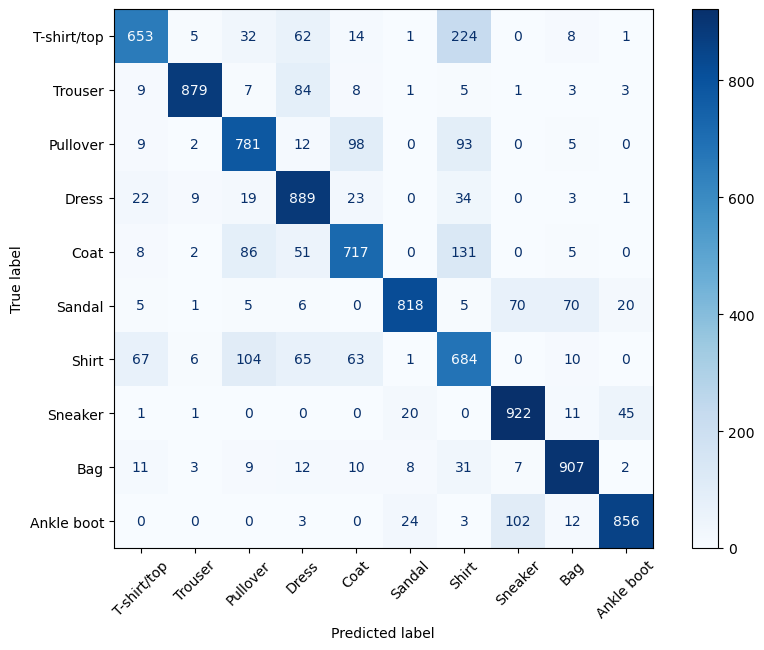

In [193]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix from predictions and labels
cm = confusion_matrix(y_true=test_data.targets, y_pred=y_pred_tensor)

# Plot using sklearn's built-in display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.xticks(rotation=45)
plt.show()


In [197]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok = True)

MODEL_NAME = "03_pytorch_comouter_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

In [203]:
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models\03_pytorch_comouter_vision_model_2.pth


In [209]:
# Making a new instance

torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape = 1, hidden_units= 10, output_shape= len(class_names))

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_2.to(device)

FashionMNISTModelV2(
  (conv_block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [213]:
#19:57:30